In [364]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import warnings

In [365]:
warnings.filterwarnings('ignore')

In [366]:
df=pd.read_csv('Data/loan_data.csv')

In [367]:
df_copy=df.copy()#make copy of original dataframe

In [368]:
df.shape

(614, 13)

Checking null values

In [369]:
columns_with_missing_data=[feature for feature in df.columns if df[feature].isnull().sum()!=0]
for col in columns_with_missing_data:
    print(col,(df[col].isnull().sum()*100/df.shape[0]),'%missing values')
    print("---------------------------")

Gender 2.1172638436482085 %missing values
---------------------------
Married 0.48859934853420195 %missing values
---------------------------
Dependents 2.44299674267101 %missing values
---------------------------
Self_Employed 5.2117263843648205 %missing values
---------------------------
LoanAmount 3.583061889250814 %missing values
---------------------------
Loan_Amount_Term 2.2801302931596092 %missing values
---------------------------
Credit_History 8.143322475570033 %missing values
---------------------------


Impute missing values

In [370]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])
df['Married']=df['Married'].fillna(df['Married'].mode()[0])
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount']=df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [371]:
#check again for missing values
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [372]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


Feature Engineering

In [373]:
df['Gender']=df['Gender'].replace({
    "Male":1,
    "Female":0
})

df['Education']=df['Education'].replace({
    "Graduate":1,
    "Not Graduate":0
})

df['Self_Employed']=df['Self_Employed'].replace({
    "No":0,
    "Yes":1
})

df['Property_Area']=df['Property_Area'].replace({
    "Urban":1,
    "Semiurban":2,
    "Rural":3
})

df['Loan_Status']=df['Loan_Status'].replace({
    "Y":1,
    "N":0
})
df['Dependents']=df['Dependents'].replace({
    "1":1,
    "2":2,
    "3+":3
})

#here we should not encode married columns beacuse it totally depends on dependent column beacuse if its not  married then 
#its value will be 0 in dependent,otherwise numerical value

#Extracting new columns or Features


df['Total_Income']=df['ApplicantIncome']+df['CoapplicantIncome']
df["LoanAmount"]=df['LoanAmount']*1000
df['Loan_Amount_Term']=df['Loan_Amount_Term']/12

#Drop the irrevelant columns

df.drop(columns=['Loan_ID','Married','ApplicantIncome','CoapplicantIncome'],axis=1,inplace=True)

In [374]:
#change the datatype for columns...
df['Gender']=df['Gender'].astype('int32')
df['Dependents']=df['Dependents'].astype('int32')
df['Education']=df['Education'].astype('int32')
df['LoanAmount']=df['LoanAmount'].astype('int64')
df['Loan_Amount_Term']=df['Loan_Amount_Term'].astype('int32')
df['Property_Area']=df['Property_Area'].astype('int32')
df['Loan_Status']=df['Loan_Status'].astype('int32')
df['Total_Income']=df['Total_Income'].astype('int32')

In [375]:
df.columns

Index(['Gender', 'Dependents', 'Education', 'Self_Employed', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'Total_Income'],
      dtype='object')

In [376]:
#Rename the columns:
df.rename(columns={
    "Dependents":"having_family",
    "LoanAmount":"Loan",
    "Loan_Amount_Term":"Repay(in years)",
    "Loan_Status":"Pass"
},inplace=True)

separate the features

In [377]:
#seaparate features
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Num of Numerical Features :', len(num_features))

categorical_feature=[col for col in df.columns if df[col].dtypes=='object']
print('Num of categorical_feature :', len(categorical_feature))


discrete_features=[col for col in df.columns if df[col].nunique()<=25]
print('Num of discrete_features :', len(discrete_features))

Continious_features=[col for col in df.columns if col not in discrete_features]
print('Num of Continious_features :', len(Continious_features))


Num of Numerical Features : 10
Num of categorical_feature : 0
Num of discrete_features : 8
Num of Continious_features : 2


In [378]:
Continious_features

['Loan', 'Total_Income']

Handling Outlier

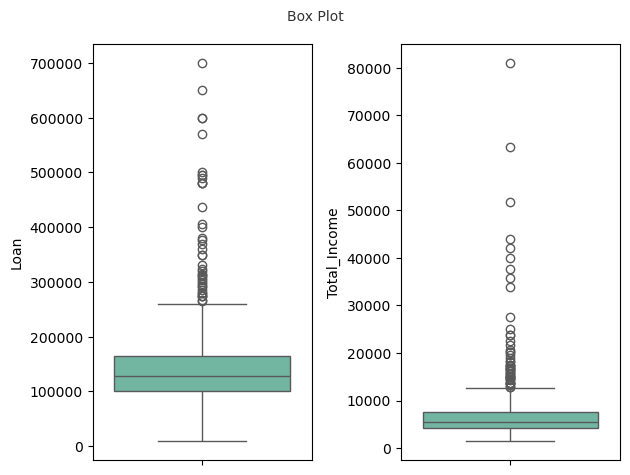

In [379]:
continious_features=Continious_features.copy()
plt.suptitle('Box Plot',fontsize=10,alpha=0.8)
for i in range(len(continious_features)):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[continious_features[i]],palette='Set2')
plt.tight_layout()
plt.show()

Outliers has very high impact on ml model and can create bias ,and we shoud deal with outlier for better model

Here,we capping the outlier because removing the outlier is not a good approach

In [380]:
#fucntion for capping outliers
def detect_outliers(feature):
    #calucalte percentile
    percentile_25=df[feature].quantile(0.25)
    percentile_75=df[feature].quantile(0.75)

    IQR=percentile_75-percentile_25
    print('IQR',IQR)

    upperlimit=percentile_75+1.5*IQR
    lowerlimit=percentile_25-1-5*IQR
    upperlimit=percentile_75+1.5*IQR
    lowerlimit=percentile_25-1.5*IQR
    print('upperlimit',upperlimit)
    print('lowerlimit',lowerlimit)
    print('---------------------------------------------------------')
  #capped the outlier..
    df.loc[(df[col]>upperlimit),col]=upperlimit
    df.loc[(df[col]<lowerlimit),col]=lowerlimit
    return df

In [381]:
for col in Continious_features:
     detect_outliers(col)

IQR 64500.0
upperlimit 261500.0
lowerlimit 3500.0
---------------------------------------------------------
IQR 3355.75
upperlimit 12555.375
lowerlimit -867.625
---------------------------------------------------------


In [382]:
#now check for skewness in data after capping of outliers
for col in df.columns:
   print(f'{col}',df[col].skew())

Gender -1.6487952886687591
having_family 1.015550985536672
Education -1.3676220101641772
Self_Employed 2.159796196971883
Loan 0.6836926591947381
Repay(in years) -2.4021122563890382
Credit_History -2.0219705924848985
Property_Area 0.06619614490788747
Pass -0.8099980938586473
Total_Income 0.942821407267383


In [383]:
num_features.remove('Total_Income')
num_features.remove('Pass')
num_features.remove('Loan')

In [384]:
df.drop(columns='Pass',axis=1 ,inplace=True)

Feature Scaling

In [385]:
#using power trasnfomer for make data more gaussian like

In [386]:
from sklearn.preprocessing import StandardScaler,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [387]:
numerical_data = Pipeline(steps=[
    ("scaling", StandardScaler())
])
cont_feature=Pipeline(steps=[
    ('powertransformer',PowerTransformer())
])


preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numerical_data, num_features),
        ("cont", cont_feature, Continious_features)
    ],)

In [388]:
columns=df.columns
scaled_data=preprocessor.fit_transform(df)
df=pd.DataFrame(scaled_data,columns=columns)

In [389]:
scaled_data.shape

(614, 9)

In [390]:
preprocessor.get_feature_names_out()

array(['numeric__Gender', 'numeric__having_family', 'numeric__Education',
       'numeric__Self_Employed', 'numeric__Repay(in years)',
       'numeric__Credit_History', 'numeric__Property_Area', 'cont__Loan',
       'cont__Total_Income'], dtype=object)

In [391]:
print('Have a look after scaling the data')
df

Have a look after scaling the data


,Gender,having_family,Education,Self_Employed,Loan,Repay(in years),Credit_History,Property_Area,Total_Income
0,0.472343,-0.737806,0.528362,-0.392601,0.273231,0.411733,-1.223298,-0.062554,0.117165
1,0.472343,0.253470,0.528362,-0.392601,0.273231,0.411733,1.318513,-0.062554,0.207152
2,0.472343,-0.737806,0.528362,2.547117,0.273231,0.411733,-1.223298,-1.409716,-1.412423
3,0.472343,-0.737806,-1.892641,-0.392601,0.273231,0.411733,-1.223298,-0.213269,-0.260799
4,0.472343,-0.737806,0.528362,-0.392601,0.273231,0.411733,-1.223298,0.172186,0.173778
...,...,...,...,...,...,...,...,...,...
609,-2.117107,-0.737806,0.528362,-0.392601,0.273231,0.411733,1.318513,-1.281161,-1.492538
610,0.472343,2.236021,0.528362,-0.392601,-2.522836,0.411733,1.318513,-2.180528,-0.682118
611,0.472343,0.253470,0.528362,-0.392601,0.273231,0.411733,-1.223298,1.845992,0.886523
612,0.472343,1.244745,0.528362,-0.392601,0.273231,0.411733,-1.223298,0.922578,0.687888


In [392]:
#restore thre Loan Status columns ,dont scale target variable

In [393]:
#Now dave this data for making model building

In [394]:
df["Loan_status"]=df_copy['Loan_Status']

In [395]:
df['Loan_status']=df['Loan_status'].replace({
    "Y":1,
    "N":0
})

In [396]:
import os 
os.makedirs("Transformed_data",exist_ok=True)
df.to_csv('Transformed_data/scaled_data.csv',index=False)

In [397]:
num_features

['Gender',
 'having_family',
 'Education',
 'Self_Employed',
 'Repay(in years)',
 'Credit_History',
 'Property_Area']

In [398]:
continious_features

['Loan', 'Total_Income']